In [1]:
import sys, os
# Agregar src/ al path para importar modulos del proyecto
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
# FASE 2 | Comprensión de los datos
---

## 2.1 Carga de datos

In [2]:
df_raw = load_raw_data(RAW_PATH, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
basic_profiling(df_raw)

[INFO] Cargando datos desde: ../data/raw/global_youtube_creator_data_large.csv
[INFO] Dataset completo: 1,000,000 filas x 12 columnas
[INFO] Muestra extraida: 100,000 filas

PERFIL BASICO DEL DATASET

Dimensiones  : 100,000 filas x 12 columnas

Tipos de dato:
timestamp           object
video_id            object
category            object
language            object
region              object
duration_sec         int64
views                int64
likes                int64
comments             int64
shares               int64
sentiment_score    float64
ads_enabled           bool
dtype: object

Valores nulos:
timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

Duplicados   : 0

Estadisticas descriptivas:
                    count unique                  top   freq         mean  

## 2.2 Descripción de variables

| Variable        | Tipo        | Descripción                                         |
|-----------------|-------------|-----------------------------------------------------|
| timestamp       | datetime    | Fecha y hora de publicacion del video               |
| video_id        | categorica  | Identificador unico del video                       |
| category        | categorica  | Categoria del contenido (6 categorias)              |
| language        | categorica  | Idioma del video (5 idiomas)                        |
| region          | categorica  | Region de origen (5 regiones)                       |
| duration_sec    | numerica    | Duracion del video en segundos [60, 3600]           |
| views           | numerica    | Numero total de visualizaciones                     |
| likes           | numerica    | Numero total de likes                               |
| comments        | numerica    | Numero total de comentarios                         |
| shares          | numerica    | Numero total de compartidos                         |
| sentiment_score | numerica    | Puntaje de sentimiento de comentarios [-1, 1]       |
| ads_enabled     | binaria     | Si el video tiene publicidad habilitada (True/False) |

## 2.3 Análisis de valores nulos y calidad

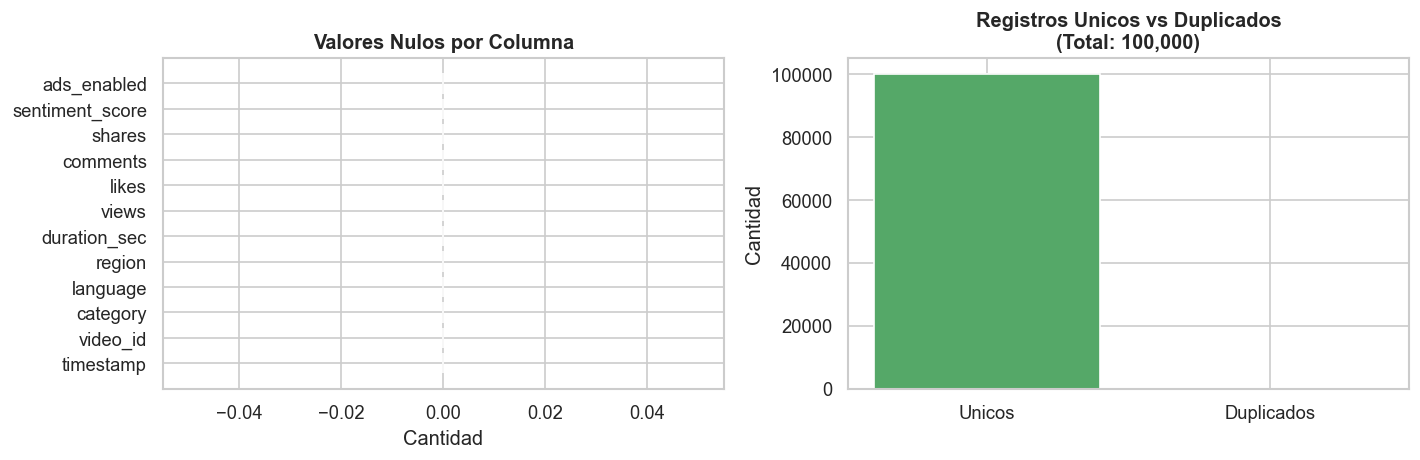

Valores nulos: 0 | Duplicados: 0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nulos
nulls = df_raw.isnull().sum()
axes[0].barh(nulls.index, nulls.values, color='#C44E52')
axes[0].set_title('Valores Nulos por Columna', fontweight='bold')
axes[0].set_xlabel('Cantidad')

# Duplicados
n_dup = df_raw.duplicated().sum()
axes[1].bar(['Unicos', 'Duplicados'], [len(df_raw) - n_dup, n_dup],
             color=['#55A868', '#C44E52'])
axes[1].set_title(f'Registros Unicos vs Duplicados\n(Total: {len(df_raw):,})', fontweight='bold')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/calidad_datos.png', bbox_inches='tight')
plt.show()
print(f'Valores nulos: {nulls.sum()} | Duplicados: {n_dup}')

## 2.4 Distribución de variables numericas de engagement

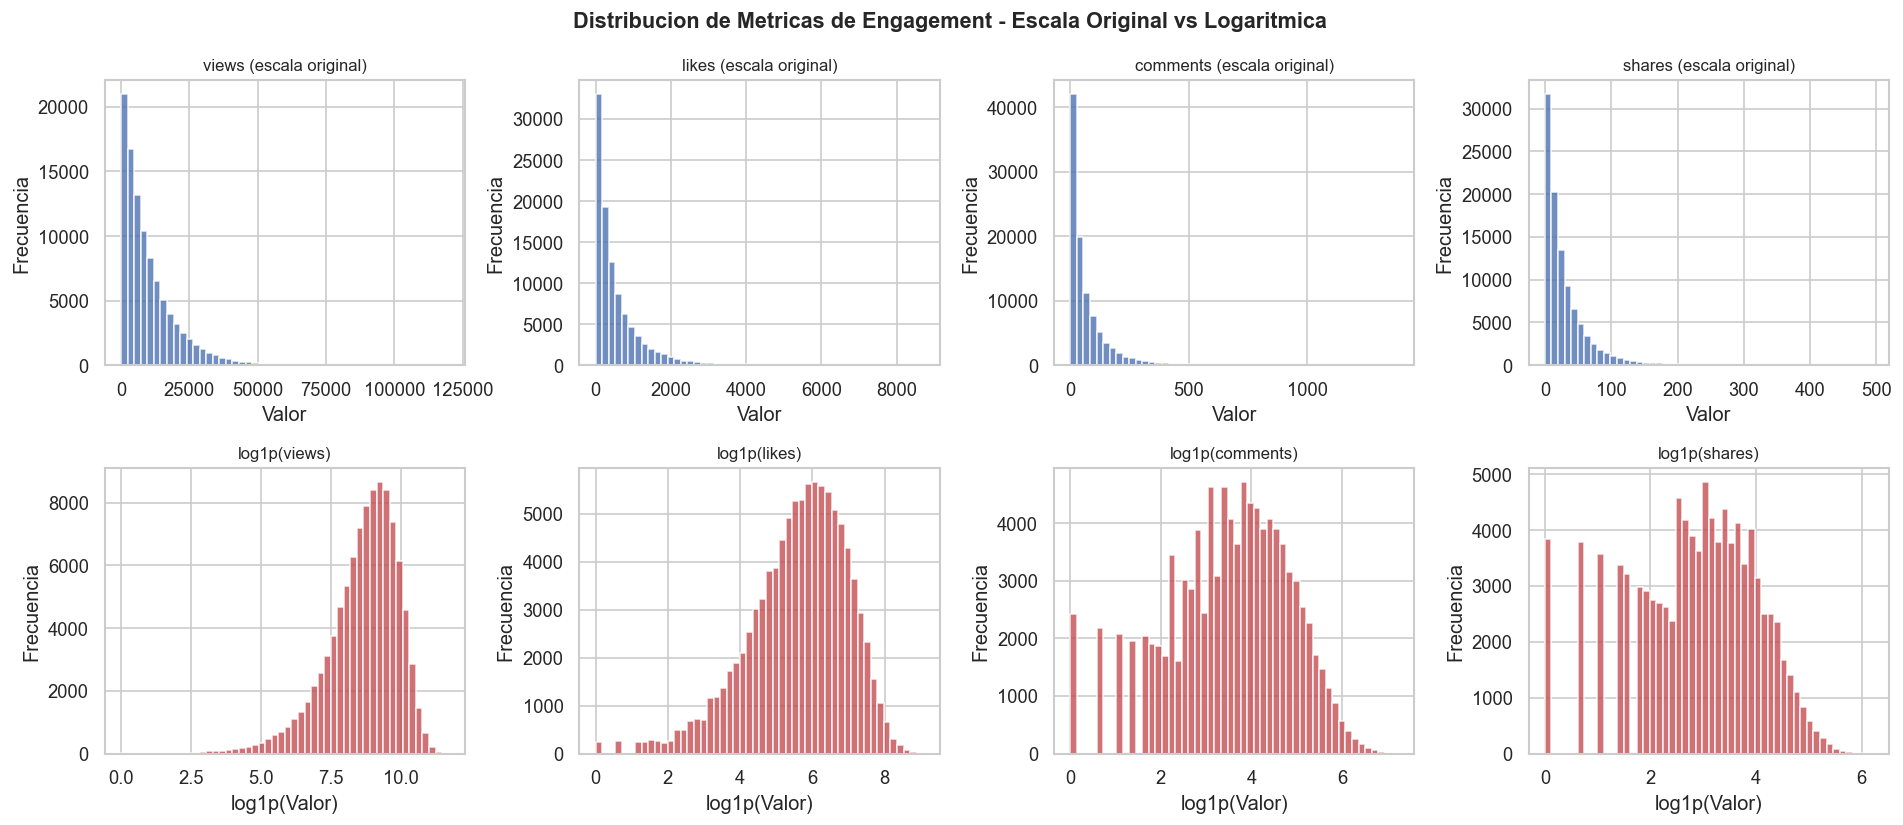


Observacion: Las metricas siguen una distribucion de cola larga (tipo ley de potencia).
La transformacion log1p simetriza la distribucion, lo cual es crucial para la
construccion del puntaje de viralidad y para el rendimiento de la regresion logistica.


In [4]:
engagement_cols = ['views', 'likes', 'comments', 'shares']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(engagement_cols):
    # Escala original
    axes[0, i].hist(df_raw[col], bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col} (escala original)', fontsize=10)
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')

    # Escala log
    axes[1, i].hist(np.log1p(df_raw[col]), bins=50, color='#C44E52', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'log1p({col})', fontsize=10)
    axes[1, i].set_xlabel('log1p(Valor)')
    axes[1, i].set_ylabel('Frecuencia')

fig.suptitle('Distribucion de Metricas de Engagement - Escala Original vs Logaritmica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/distribucion_engagement.png', bbox_inches='tight')
plt.show()

print('\nObservacion: Las metricas siguen una distribucion de cola larga (tipo ley de potencia).')
print('La transformacion log1p simetriza la distribucion, lo cual es crucial para la')
print('construccion del puntaje de viralidad y para el rendimiento de la regresion logistica.')

## 2.5 Análisis de variables categóricas

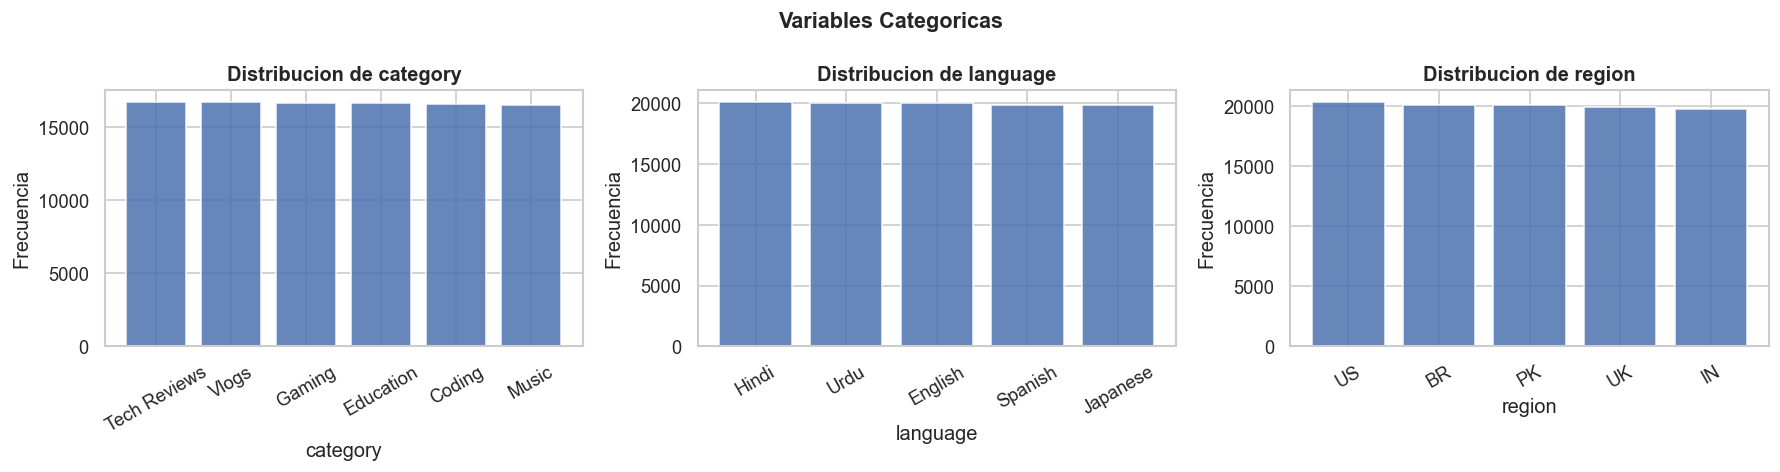

In [5]:
cat_cols = ['category', 'language', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    counts = df_raw[col].value_counts()
    ax.bar(counts.index, counts.values, color='#4C72B0', alpha=0.85)
    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Variables Categoricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/distribucion_categoricas.png', bbox_inches='tight')
plt.show()

## 2.6 Matriz de correlación


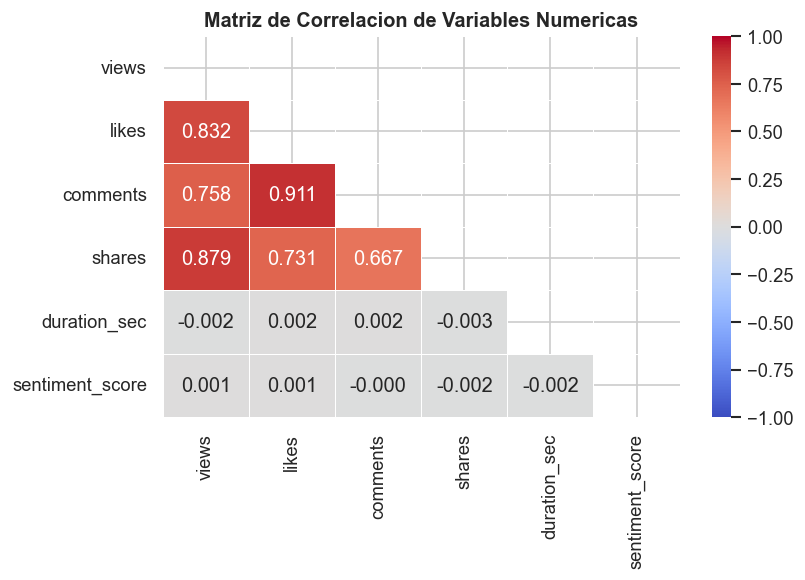


Hallazgos clave:
  - Correlacion views-likes    : 0.832
  - Correlacion views-comments : 0.758
  - Correlacion views-shares   : 0.879
  - Correlacion likes-comments : 0.911


In [6]:
num_cols = ['views', 'likes', 'comments', 'shares', 'duration_sec', 'sentiment_score']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlacion de Variables Numericas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlacion.png', bbox_inches='tight')
plt.show()

print('\nHallazgos clave:')
print(f'  - Correlacion views-likes    : {corr.loc["views","likes"]:.3f}')
print(f'  - Correlacion views-comments : {corr.loc["views","comments"]:.3f}')
print(f'  - Correlacion views-shares   : {corr.loc["views","shares"]:.3f}')
print(f'  - Correlacion likes-comments : {corr.loc["likes","comments"]:.3f}')

## 2.7 Engagement promedio por categoría

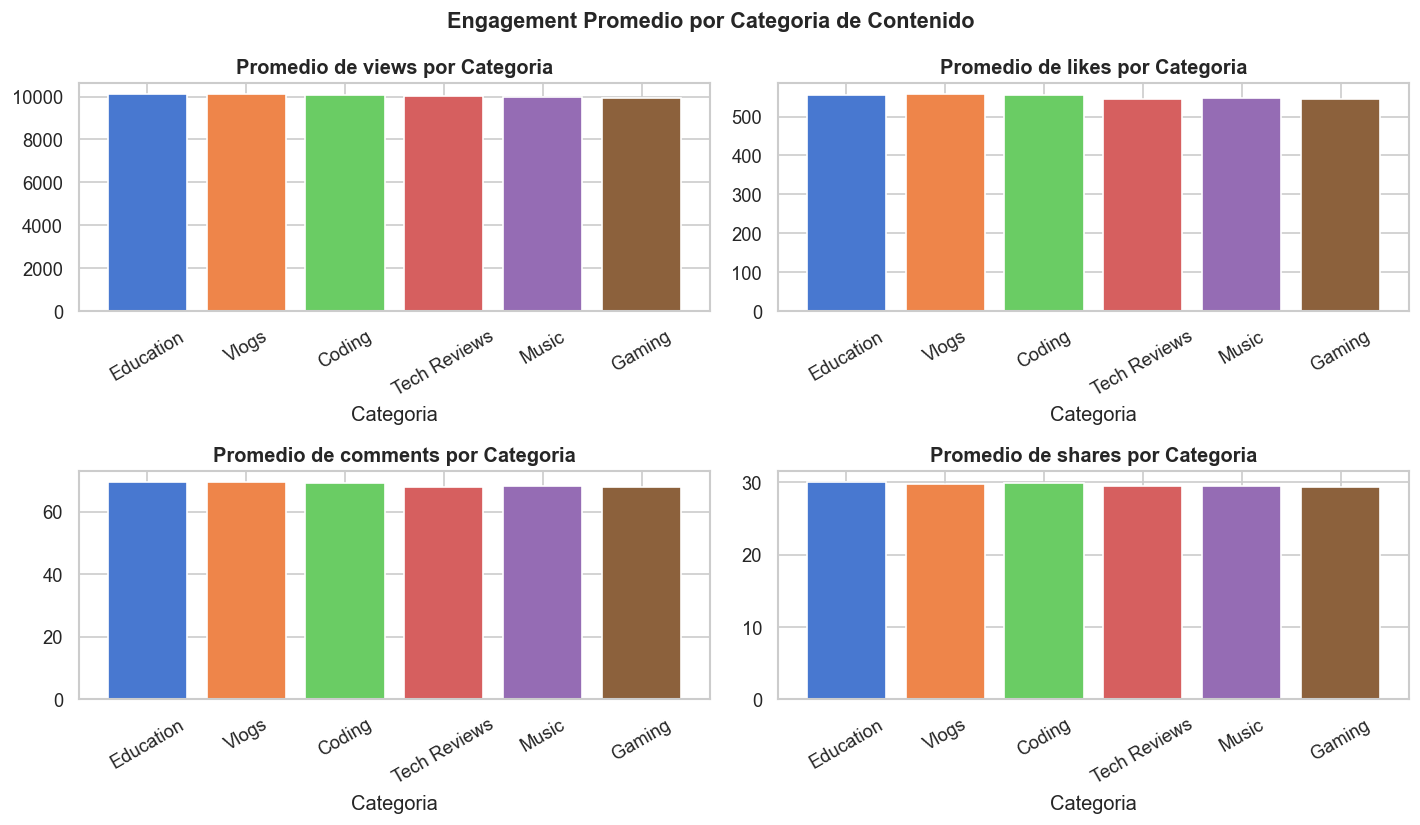

In [7]:
engagement_by_cat = df_raw.groupby('category')[engagement_cols].mean().sort_values('views', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
colors = sns.color_palette('muted', len(engagement_by_cat))

for ax, col in zip(axes.flat, engagement_cols):
    bars = ax.bar(engagement_by_cat.index, engagement_by_cat[col], color=colors)
    ax.set_title(f'Promedio de {col} por Categoria', fontweight='bold')
    ax.set_xlabel('Categoria')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Engagement Promedio por Categoria de Contenido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/engagement_por_categoria.png', bbox_inches='tight')
plt.show()

In [8]:
import pickle, os

os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/df_raw.pkl', 'wb') as f:
    pickle.dump(df_raw, f)

print(f" df_raw guardado: {df_raw.shape}")

 df_raw guardado: (100000, 12)
